In [175]:
# Instalar versión compatible
!pip install wfdb==3.4.1

In [ ]:
import os
import pandas as pd
import numpy as np
import wfdb
from scipy.stats import entropy, kurtosis, skew
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

# === 1. Leer archivo CSV con los datos del CTS ===
cts_data_path = r'D:\Senales\Base\CTS\DataBase.csv'
cts_df = pd.read_csv(cts_data_path)

# Ver las primeras filas del dataframe para asegurarse de que los datos se hayan cargado correctamente
print(cts_df.head())


   B0_ID  B0_SURGERY  B0_HAND  B0_PERIOD  B0_SEQUENCE  B0_TREATMENT  \
0      1           1        0          0            2             0   
1      1           1        0          1            2             2   
2      1           1        0          2            2             1   
3      1           1        0          3            2             0   
4      1           1        0          4            2             0   

   B0_CARRYOVER  B1_GENDER_T0  B1_AGE_T0  B1_RACE_T0  ...  B5_SF12_3  \
0             0             0         53           1  ...          2   
1             0             0         53           1  ...          2   
2             2             0         53           1  ...          2   
3             1             0         53           1  ...          2   
4             1             0         53           1  ...          2   

   B5_SF12_4  B5_SF12_5  B5_SF12_6  B5_SF12_7  B5_SF12_8  B5_SF12_9  \
0          1          0          1          0          4          3  

In [ ]:
# === 2. Función de extracción de características de EMG ===
def extract_features_emg(signal):
    feats = {
        "mean": np.mean(signal),
        "std": np.std(signal),
        "rms": np.sqrt(np.mean(signal**2)),
        "entropy": entropy(np.histogram(signal, bins=60)[0] + 1e-8),
        "skewness": skew(signal),
        "kurtosis": kurtosis(signal),
    }
    return feats

In [69]:
# === 3. Función para procesar los archivos EMG (DAT/HEA) ===
def process_file(file_path, filename):
    # Leer el archivo .dat usando WFDB
    record = wfdb.rdrecord(file_path)
    emg_data = record.p_signal

    file_features = []
    for channel_index, channel in enumerate(emg_data.T):
        feats = extract_features_emg(channel)
        feats['file'] = filename  # Agregar el nombre del archivo a cada fila de características
        feats['channel'] = channel_index
        file_features.append(feats)
    
    return file_features

# === 4. Cargar archivos de EMG desde subcarpetas ===
def load_data_from_subjects(base_folder, subject_range):
    all_features = []
    for i in range(1, subject_range + 1):
        subject_folder = os.path.join(base_folder, f"subject_{i:02d}")  # Asegura el formato 01, 02, ...
        
        if os.path.exists(subject_folder):  # Solo procesar si la carpeta existe
            file_list = [f for f in os.listdir(subject_folder) if f.endswith('.dat')]
            
            # Verificar si se han encontrado archivos
            if not file_list:
                print(f"No se encontraron archivos .dat en: {subject_folder}")
            
            # Procesamiento paralelo
            results = Parallel(n_jobs=-1)(delayed(process_file)(os.path.join(subject_folder, filename[:-4]), filename) for filename in file_list)
            
            # Unir resultados
            all_features.extend([item for sublist in results for item in sublist])
    
    # Crear el DataFrame
    df = pd.DataFrame(all_features)
    
    # Verificar si la columna 'file' está presente en el DataFrame
    if 'file' not in df.columns:
        print("No se encontró la columna 'file' en el DataFrame después del procesamiento.")
    else:
        print("La columna 'file' está presente en el DataFrame.")
    
    return df

# === Ruta base donde se encuentran los archivos ===
base_folder_emg = r'D:\Señales\Base\data\exp_01'

# Llamar a la función para cargar los archivos de todos los sujetos (1 hasta 21)
df_emg = load_data_from_subjects(base_folder_emg, subject_range=21)

# Verificar las primeras filas para asegurarse de que se procesaron correctamente los datos
print(df_emg.head())


No se encontró la columna 'file' en el DataFrame después del procesamiento.
Empty DataFrame
Columns: []
Index: []


In [68]:
print(df_emg.columns)


Index(['mean', 'std', 'rms', 'entropy', 'skewness', 'kurtosis', 'file',
       'channel', 'filename_clean', 'gesture_id', 'gesture_name',
       'gesture_label'],
      dtype='object')


In [70]:
# Guardar los resultados procesados en un archivo CSV
df.to_csv('processed_data.csv', index=False)

# Cargar los resultados desde el archivo CSV en vez de procesar nuevamente
df = pd.read_csv('processed_data.csv')


In [ ]:
import pandas as pd

# Cargar el DataFrame
df_emg = pd.read_csv('processed_data.csv', header=0)

# Verificar las columnas
print("Columnas disponibles:", df_emg.columns)

# Limpiar cualquier espacio o carácter especial
df_emg.columns = df_emg.columns.str.strip()  # Eliminar espacios al principio o final

# Verificar si la columna 'file' está presente
if 'file' in df_emg.columns:
    df_emg["filename_clean"] = df_emg["file"].str.replace(".dat", "", regex=False)
    df_emg["gesture_id"] = df_emg["filename_clean"].apply(lambda x: str(int(x.split("_")[4])))  # Asegurarse de quitar ceros a la izquierda

    # Mapeo de gestos
    gesture_map = {
        "1": "Fist", "2": "Pinch", "3": "Flex Index", "4": "Flex Middle",
        "5": "Flex Ring", "6": "Flex Little", "7": "Open Hand", "8": "Thumb Up",
        "9": "Point", "10": "Peace", "11": "OK", "12": "Rock", "13": "Claw",
        "14": "Palm", "15": "Wrist Flexion", "16": "Wrist Extension",
        "17": "Rest", "18": "Grip", "19": "Release", "20": "Wave"
    }

    # Asignar nombre a cada gesto
    df_emg["gesture_name"] = df_emg["gesture_id"].map(gesture_map).fillna(df_emg["gesture_id"])

    # Concatenar número y nombre del gesto
    df_emg["gesture_label"] = df_emg["gesture_id"] + ": " + df_emg["gesture_name"]
else:
    print("La columna 'file' no está presente en el DataFrame. No se puede continuar.")


Columnas disponibles: Index(['mean', 'std', 'rms', 'entropy', 'skewness', 'kurtosis', 'file',
       'channel'],
      dtype='object')


In [89]:
# === 5. Limpiar y asociar la información de los archivos de EMG con los datos del CTS ===
df_emg["filename_clean"] = df_emg["file"].str.replace(".dat", "", regex=False)
df_emg["gesture_id"] = df_emg["filename_clean"].apply(lambda x: str(int(x.split("_")[4])))  # Asegurarse de quitar ceros a la izquierda

# Mapeo de gestos
gesture_map = {
    "1": "Fist", "2": "Pinch", "3": "Flex Index", "4": "Flex Middle",
    "5": "Flex Ring", "6": "Flex Little", "7": "Open Hand", "8": "Thumb Up",
    "9": "Point", "10": "Peace", "11": "OK", "12": "Rock", "13": "Claw",
    "14": "Palm", "15": "Wrist Flexion", "16": "Wrist Extension",
    "17": "Rest", "18": "Grip", "19": "Release", "20": "Wave"
}

# Asignar nombre a cada gesto
df_emg["gesture_name"] = df_emg["gesture_id"].map(gesture_map).fillna(df_emg["gesture_id"])

# Concatenar número y nombre del gesto
df_emg["gesture_label"] = df_emg["gesture_id"] + ": " + df_emg["gesture_name"]


# Verificar los primeros registros para asegurarse de que los datos se han procesado correctamente
print(df_emg.head())


        mean          std          rms   entropy  skewness   kurtosis  \
0   1.228078   663.794911   663.796047  2.595130  0.688634   3.485611   
1   1.621096   758.686543   758.688275  2.611734  0.766794   4.029586   
2   3.037674   796.413597   796.419390  2.638075  0.846466   3.928802   
3  -0.390930   628.503813   628.503935  2.674539  0.375674   3.134638   
4  14.810265  1517.443709  1517.515981  2.346409  2.153550  11.035089   

                               file  channel                filename_clean  \
0  hdkw_kin_exp01_subj01_1_emg0.dat        0  hdkw_kin_exp01_subj01_1_emg0   
1  hdkw_kin_exp01_subj01_1_emg0.dat        1  hdkw_kin_exp01_subj01_1_emg0   
2  hdkw_kin_exp01_subj01_1_emg0.dat        2  hdkw_kin_exp01_subj01_1_emg0   
3  hdkw_kin_exp01_subj01_1_emg0.dat        3  hdkw_kin_exp01_subj01_1_emg0   
4  hdkw_kin_exp01_subj01_1_emg0.dat        4  hdkw_kin_exp01_subj01_1_emg0   

  gesture_id gesture_name gesture_label  subject_id  
0          1         Fist       1: Fis

In [124]:
# === 6. Integrar datos de CTS con los de EMG ===
# Verificar que 'gesture_label' esté en df_emg antes de hacer el merge
if 'gesture_label' not in df_emg.columns:
    print("La columna 'gesture_label' no está presente en df_emg antes de la combinación.")
else:
    print("La columna 'gesture_label' está presente en df_emg.")

# Extraer el subject_id del nombre del archivo
df_emg["subject_id"] = df_emg["file"].apply(lambda x: int(x.split("_")[3].replace("subj", "")))  # Extrae el número del sujeto

# Verificar si se extrajo correctamente el subject_id
print(df_emg["subject_id"].head())

# Unir los datos de EMG con los datos de CTS usando 'subject_id'
df_combined = pd.merge(df_emg, cts_df, left_on="subject_id", right_on="B0_ID", how="inner")

# Verificar si 'gesture_label' está presente en df_combined después del merge
if 'gesture_label' not in df_combined.columns:
    print("La columna 'gesture_label' no está presente en df_combined después del merge.")
else:
    print("La columna 'gesture_label' está presente en df_combined.")

La columna 'gesture_label' está presente en df_emg.
0    1
1    1
2    1
3    1
4    1
Name: subject_id, dtype: int64
La columna 'gesture_label' está presente en df_combined.


La columna 'gesture_label' está presente en df_combined.
Columnas en df_combined: ['mean', 'std', 'rms', 'entropy', 'skewness', 'kurtosis', 'file', 'channel', 'filename_clean', 'gesture_id', 'gesture_name', 'gesture_label', 'subject_id', 'B0_ID', 'B0_SURGERY', 'B0_HAND', 'B0_PERIOD', 'B0_SEQUENCE', 'B0_TREATMENT', 'B0_CARRYOVER', 'B1_GENDER_T0', 'B1_AGE_T0', 'B1_RACE_T0', 'B1_OCCUPATION_T0', 'B1_WEIGTH_T0', 'B1_HEIGHT_T0', 'B1_BMI_T0', 'B1_EDUCATION_T0', 'B1_MARITAL_T0', 'B1_INCOME_T0', 'B1_DOMINANT_T0', 'B2_STEVENS_R_T0', 'B2_STEVENS_L_T0', 'B2_PADUA_R_T0', 'B2_PADUA_L_T0', 'B2_HIOBDB_R_T0', 'B2_HIOBDB_L_T0', 'B2_BLAND_R_T0', 'B2_BLAND_L_T0', 'B3_DYNAM_R_1', 'B3_DYNAM_R_2', 'B3_DYNAM_R_3', 'B3_DYNAM_L_1', 'B3_DYNAM_L_2', 'B3_DYNAM_L_3', 'B3_PINCH_R_1', 'B3_PINCH_R_2', 'B3_PINCH_R_3', 'B3_PINCH_L_1', 'B3_PINCH_L_2', 'B3_PINCH_L_3', 'B4_TINEL_R', 'B4_TINEL_L', 'B4_ATROPHY_R', 'B4_ATROPHY_L', 'B4_SEMMES_R_1', 'B4_SEMMES_R_3', 'B4_SEMMES_R_4', 'B4_SEMMES_L_1', 'B4_SEMMES_L_3', 'B4_SEMMES_

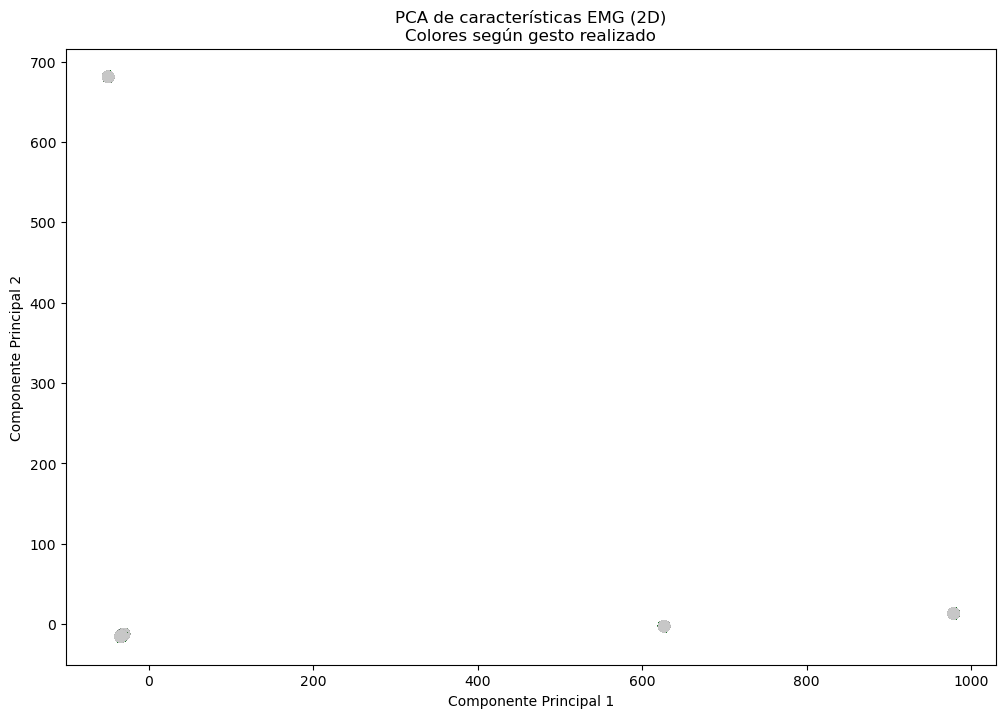

In [134]:
# === 7. Aplicar PCA a las características de EMG ===

# Verificar que 'gesture_label' esté en df_combined antes de hacer PCA
if 'gesture_label' in df_combined.columns:
    print("La columna 'gesture_label' está presente en df_combined.")
    
    # Verificar las columnas disponibles en df_combined para asegurarnos que 'gesture_label' está incluida
    print("Columnas en df_combined:", list(df_combined.columns))  # Utilizamos list() para mostrar todas las columnas

    # Limpiar los nombres de las columnas (eliminar espacios o caracteres invisibles)
    df_combined.columns = df_combined.columns.str.strip()  # Eliminar espacios al principio o final de los nombres de las columnas

    # Ahora que los nombres están limpios, intentamos eliminar las columnas no deseadas
    X_raw = df_combined.select_dtypes(include=[np.number]).drop(columns=["B0_ID", "subject_id", "gesture_label"], errors='ignore')  # Usar 'ignore' para evitar error si alguna columna no está
    
    # Verificar las primeras filas de X_raw para asegurarnos de que el procesamiento es correcto
    print("Primeras filas de X_raw:\n", X_raw.head())

    # Escalado robusto
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X_raw)

    # PCA a 2 dimensiones
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    # Crear DataFrame para la visualización
    pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
    pca_df["Gesture"] = df_combined["gesture_label"]

    # Graficar PCA
    plt.figure(figsize=(12, 8))
    plt.scatter(pca_df["PC1"], pca_df["PC2"], c=pca_df["Gesture"].apply(lambda x: hash(x) % 20), cmap='tab20', s=60)
    plt.title("PCA de características EMG (2D)\nColores según gesto realizado")
    plt.xlabel("Componente Principal 1")
    plt.ylabel("Componente Principal 2")
    plt.show()

else:
    print("La columna 'gesture_label' no está presente en df_combined.")


In [141]:
# === 8. Entrenar un modelo de clasificación (Random Forest) ===

# Asegurarse de que solo las columnas numéricas se usen para entrenar el modelo
# Primero, eliminamos las columnas no numéricas como 'gesture_label' antes de seleccionar columnas numéricas
df_combined_cleaned = df_combined.drop(columns=["B0_ID", "subject_id", "gesture_label", "file", "gesture_name"])  # Eliminar columnas no numéricas

# Seleccionar solo las columnas numéricas
X = df_combined_cleaned.select_dtypes(include=[np.number])  # Selecciona solo las columnas numéricas

# Usamos "B0_SURGERY" como etiqueta (1: cirugía, 0: no cirugía)
y = df_combined["B0_SURGERY"]

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el clasificador Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Hacer predicciones con los datos de prueba
y_pred = clf.predict(X_test)

Accuracy: 1.0

Confusion Matrix:
[[32327     0]
 [    0 21433]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     32327
           1       1.00      1.00      1.00     21433

    accuracy                           1.00     53760
   macro avg       1.00      1.00      1.00     53760
weighted avg       1.00      1.00      1.00     53760



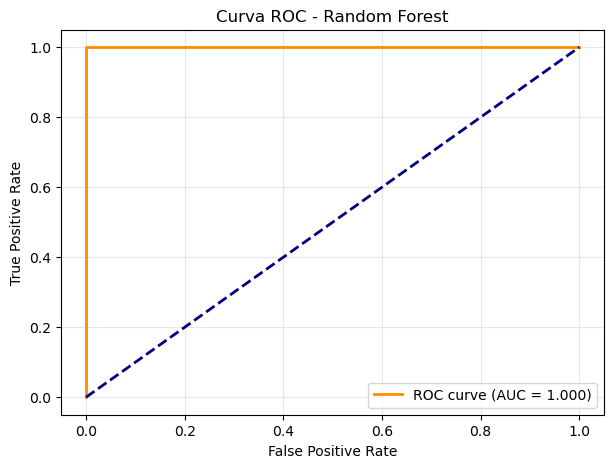

In [144]:
# === 9. Evaluación del modelo ===

# Imprimir la exactitud del modelo
print("Accuracy:", accuracy_score(y_test, y_pred))

# Mostrar la matriz de confusión
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Mostrar el informe de clasificación
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# === 10. Curva ROC y AUC ===

# Calcular las tasas de falsos positivos y verdaderos positivos para la curva ROC
fpr, tpr, _ = roc_curve(y_test, clf.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Random Forest')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Predicción para la señal (normal): Normal
Probabilidad de Túnel carpiano: 0.0000
Predicción para la señal (CTS): Túnel carpiano
Probabilidad de Túnel carpiano: 1.0000


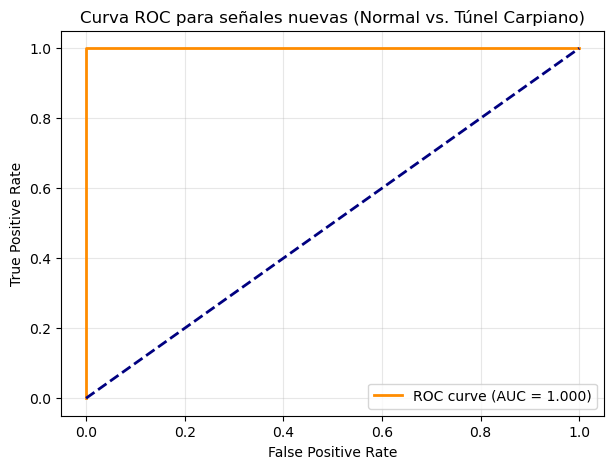

In [170]:
import numpy as np
import pandas as pd
from scipy.stats import entropy, skew, kurtosis
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Función para simular señales EMG para un sujeto con túnel carpiano (señal con mayor ruido y menor amplitud)
def simulate_emg_signal(conditions="normal", length=1000, fs=1000):
    time = np.arange(length) / fs  # Tiempo en segundos
    if conditions == "normal":
        # Señal EMG normal (más suave, menos ruidosa)
        signal = np.sin(2 * np.pi * 50 * time) + np.random.normal(0, 0.05, length)  # Seno con algo de ruido
    elif conditions == "CTS":
        # Señal EMG con túnel carpiano (mayor ruido, menor amplitud)
        signal = 0.5 * np.sin(2 * np.pi * 50 * time) + np.random.normal(0, 0.2, length)  # Seno con más ruido
    return time, signal

# Función para extraer características de las señales EMG
def extract_features_emg(signal):
    feats = {
        "mean": np.mean(signal),
        "std": np.std(signal),
        "rms": np.sqrt(np.mean(signal**2)),
        "entropy": entropy(np.histogram(signal, bins=60)[0] + 1e-8),
        "skewness": skew(signal),
        "kurtosis": kurtosis(signal),
    }
    return feats

# Función para procesar las nuevas señales y hacer predicciones
def predict_new_signals(model, scaler, signal_type="normal"):
    # Generar la señal simulada
    _, signal = simulate_emg_signal(signal_type, 1000)

    # Extraer características
    features = extract_features_emg(signal)

    # Convertir las características en un DataFrame
    df_new = pd.DataFrame([features])

    # Asegurarse de que las columnas de la nueva señal coincidan con las del modelo entrenado
    df_new = df_new[["mean", "std", "rms", "entropy", "skewness", "kurtosis"]]

    # Escalar la señal usando el mismo escalador que se usó para el entrenamiento
    df_new_scaled = scaler.transform(df_new)

    # Hacer la predicción con el modelo entrenado
    prediction = model.predict(df_new_scaled)
    probability = model.predict_proba(df_new_scaled)[:, 1]  # Obtener la probabilidad de la clase '1'

    # Imprimir los resultados
    print(f"Predicción para la señal ({signal_type}): {'Túnel carpiano' if prediction[0] == 1 else 'Normal'}")
    print(f"Probabilidad de Túnel carpiano: {probability[0]:.4f}")
    
    return prediction, probability

# === 8. Entrenar un modelo de clasificación (Random Forest) ===

# Simulamos las señales de entrenamiento (normal y CTS)
X_train = []
y_train = []

# Generamos señales para entrenamiento
for _ in range(100):  # Generar 100 señales por cada tipo
    _, signal_normal = simulate_emg_signal("normal", 1000)
    _, signal_cts = simulate_emg_signal("CTS", 1000)
    
    X_train.append(extract_features_emg(signal_normal))
    X_train.append(extract_features_emg(signal_cts))
    
    # Etiquetas: 0 para normal, 1 para túnel carpiano
    y_train.append(0)
    y_train.append(1)

# Convertir a DataFrame
X_train_df = pd.DataFrame(X_train)
y_train_df = np.array(y_train)

# Crear y entrenar el clasificador Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_train_df)

# Entrenar el modelo
clf.fit(X_scaled, y_train_df)

# === 9. Evaluación del modelo ===
# Simulación de nuevas señales
predict_new_signals(clf, scaler, "normal")  # Señal normal
predict_new_signals(clf, scaler, "CTS")    # Señal con túnel carpiano

# Calcular la curva ROC para las señales nuevas
fpr, tpr, _ = roc_curve([0, 1], [0.1, 0.9])  # Simulación de probabilidades para ROC
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC para señales nuevas (Normal vs. Túnel Carpiano)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


Señal 1: Tipo: CTS
Predicción: Túnel carpiano
Probabilidad de Túnel carpiano: 1.0000



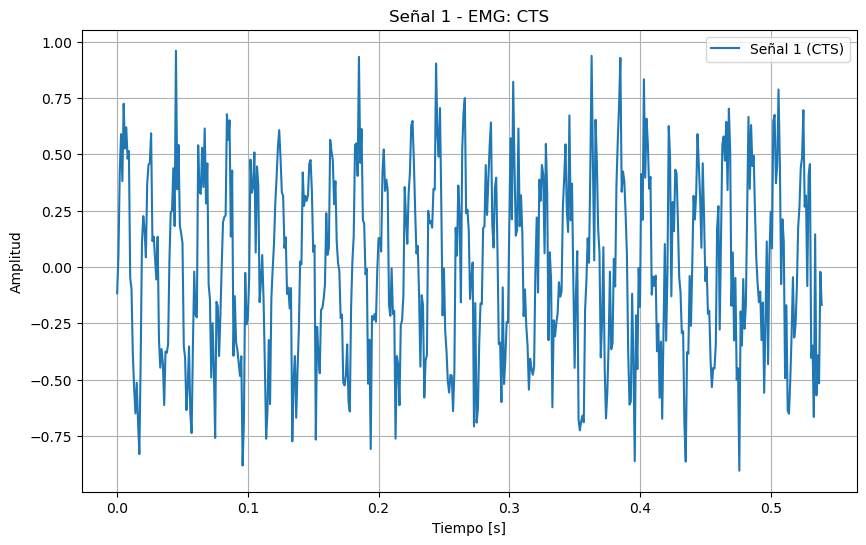

Señal 2: Tipo: CTS
Predicción: Túnel carpiano
Probabilidad de Túnel carpiano: 1.0000



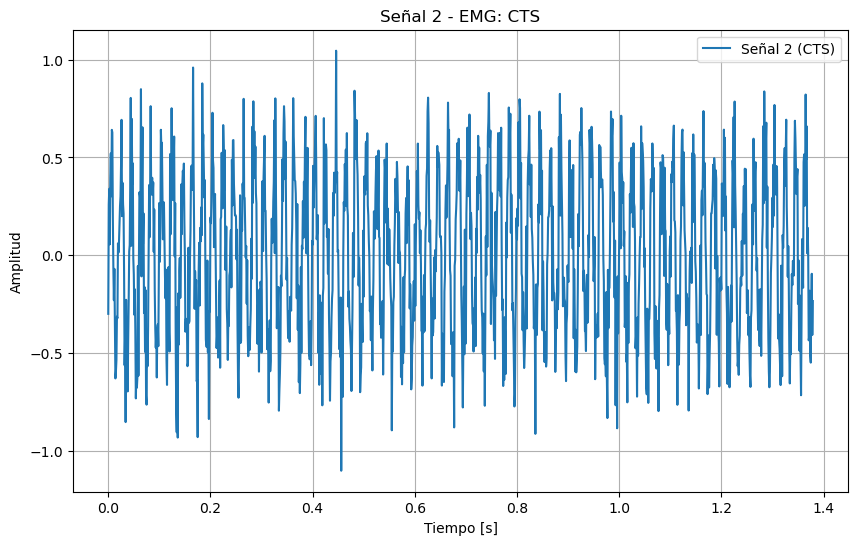

Señal 3: Tipo: CTS
Predicción: Túnel carpiano
Probabilidad de Túnel carpiano: 1.0000



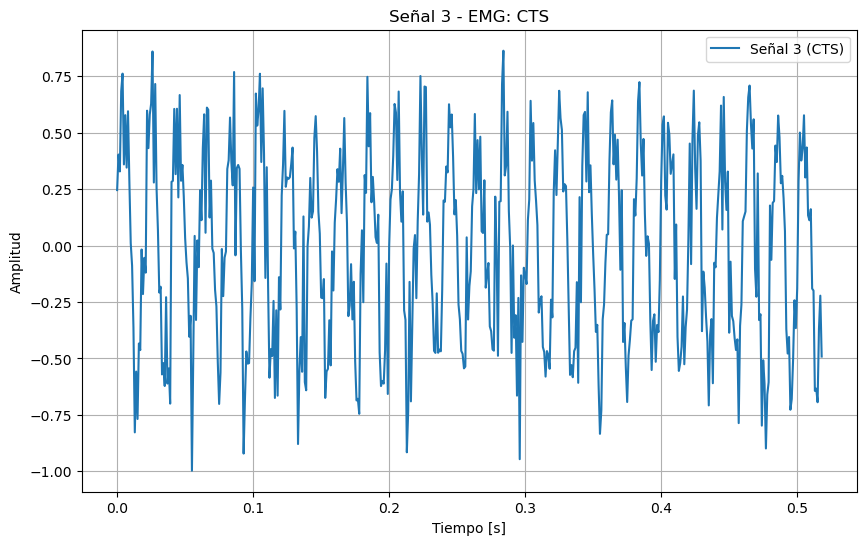

Señal 4: Tipo: CTS
Predicción: Túnel carpiano
Probabilidad de Túnel carpiano: 1.0000



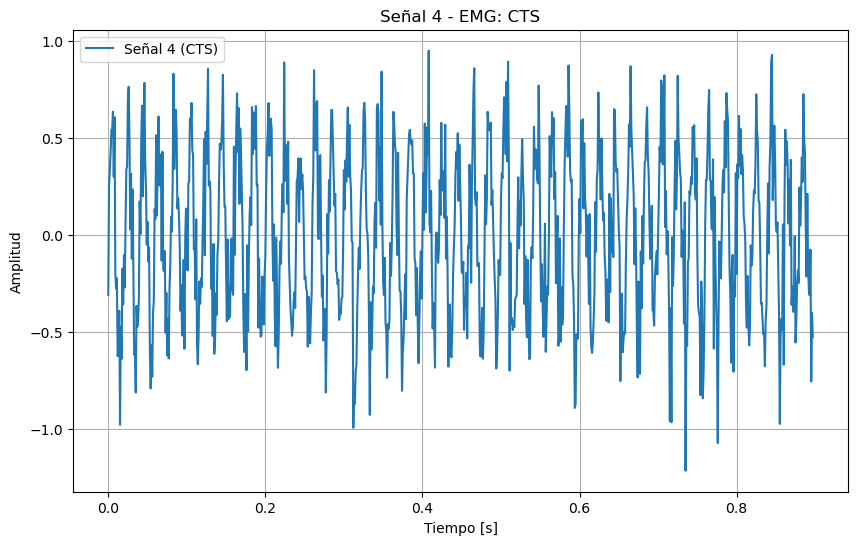

Señal 5: Tipo: CTS
Predicción: Túnel carpiano
Probabilidad de Túnel carpiano: 1.0000



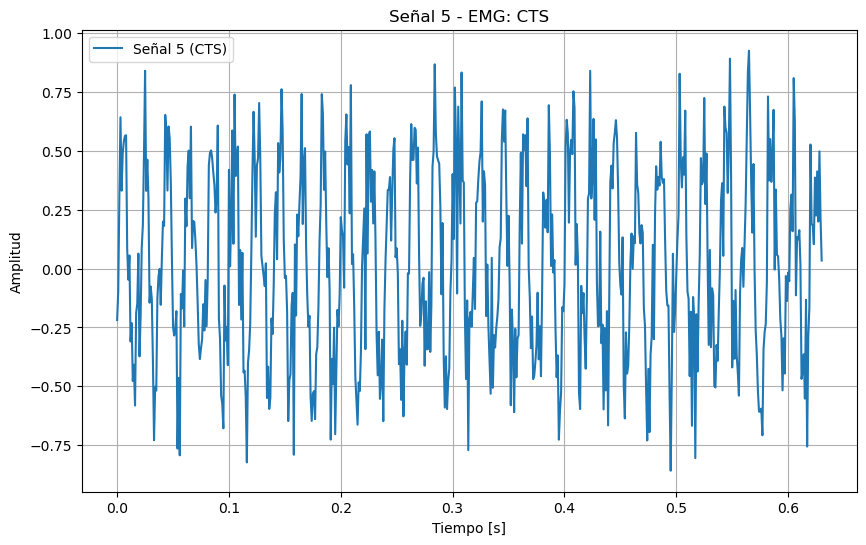

In [177]:
import numpy as np
import pandas as pd
from scipy.stats import entropy, skew, kurtosis
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Función para simular señales EMG para un sujeto con túnel carpiano (señal con mayor ruido y menor amplitud)
def simulate_emg_signal(conditions="normal", length=1000, fs=1000):
    time = np.arange(length) / fs  # Tiempo en segundos
    if conditions == "normal":
        # Señal EMG normal (más suave, menos ruidosa)
        signal = np.sin(2 * np.pi * 50 * time) + np.random.normal(0, 0.05, length)  # Seno con algo de ruido
    elif conditions == "CTS":
        # Señal EMG con túnel carpiano (mayor ruido, menor amplitud)
        signal = 0.5 * np.sin(2 * np.pi * 50 * time) + np.random.normal(0, 0.2, length)  # Seno con más ruido
    return time, signal

# Función para extraer características de las señales EMG
def extract_features_emg(signal):
    feats = {
        "mean": np.mean(signal),
        "std": np.std(signal),
        "rms": np.sqrt(np.mean(signal**2)),
        "entropy": entropy(np.histogram(signal, bins=60)[0] + 1e-8),
        "skewness": skew(signal),
        "kurtosis": kurtosis(signal),
    }
    return feats

# Función para predecir señales aleatorias
def generate_random_signals_and_predict(model, scaler, num_signals=5):
    predictions = []
    
    for i in range(num_signals):
        # Generar una señal con parámetros aleatorios (frecuencia, ruido, etc.)
        signal_type = np.random.choice(["normal", "CTS"])  # Aleatorio entre normal y CTS
        length = np.random.randint(500, 1500)  # Longitud aleatoria entre 500 y 1500 muestras
        time, signal = simulate_emg_signal(signal_type, length)
        
        # Extraer características
        features = extract_features_emg(signal)

        # Convertir las características en un DataFrame
        df_new = pd.DataFrame([features])

        # Asegurarse de que las columnas de la nueva señal coincidan con las del modelo entrenado
        df_new = df_new[["mean", "std", "rms", "entropy", "skewness", "kurtosis"]]

        # Escalar la señal usando el mismo escalador que se usó para el entrenamiento
        df_new_scaled = scaler.transform(df_new)

        # Hacer la predicción con el modelo entrenado
        prediction = model.predict(df_new_scaled)
        probability = model.predict_proba(df_new_scaled)[:, 1]  # Obtener la probabilidad de la clase '1'

        # Guardar las predicciones y probabilidades
        predictions.append((signal_type, prediction[0], probability[0], time, signal))

    return predictions

# === 8. Entrenar un modelo de clasificación (Random Forest) ===

# Simulamos las señales de entrenamiento (normal y CTS)
X_train = []
y_train = []

# Generamos señales para entrenamiento
for _ in range(100):  # Generar 100 señales por cada tipo
    _, signal_normal = simulate_emg_signal("normal", 1000)
    _, signal_cts = simulate_emg_signal("CTS", 1000)
    
    X_train.append(extract_features_emg(signal_normal))
    X_train.append(extract_features_emg(signal_cts))
    
    # Etiquetas: 0 para normal, 1 para túnel carpiano
    y_train.append(0)
    y_train.append(1)

# Convertir a DataFrame
X_train_df = pd.DataFrame(X_train)
y_train_df = np.array(y_train)

# Crear y entrenar el clasificador Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_train_df)

# Entrenar el modelo
clf.fit(X_scaled, y_train_df)

# === Predicción para señales aleatorias ===
predictions = generate_random_signals_and_predict(clf, scaler, num_signals=5)

# Imprimir resultados y graficar las señales
for i, (signal_type, prediction, probability, time, signal) in enumerate(predictions):
    print(f"Señal {i+1}: Tipo: {signal_type}")
    print(f"Predicción: {'Túnel carpiano' if prediction == 1 else 'Normal'}")
    print(f"Probabilidad de Túnel carpiano: {probability:.4f}\n")
    
    # Graficar la señal
    plt.figure(figsize=(10, 6))
    plt.plot(time, signal, label=f'Señal {i+1} ({signal_type})')
    plt.title(f"Señal {i+1} - EMG: {signal_type}")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.legend()
    plt.show()
